In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.io import loadmat
from sklearn.metrics import classification_report

In [2]:
data =loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex3data1.mat")
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Oct 16 13:09:09 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(5000, 400)),
 'y': array([[10],
        [10],
        [10],
        ...,
        [ 9],
        [ 9],
        [ 9]], shape=(5000, 1), dtype=uint8)}

In [4]:
data['X'].shape,data['y'].shape

((5000, 400), (5000, 1))

In [5]:
sample_idx = np.random.choice(np.arange(data['X'].shape[0]),100)
sample_images = data['X'][sample_idx,:]
sample_images

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 400))

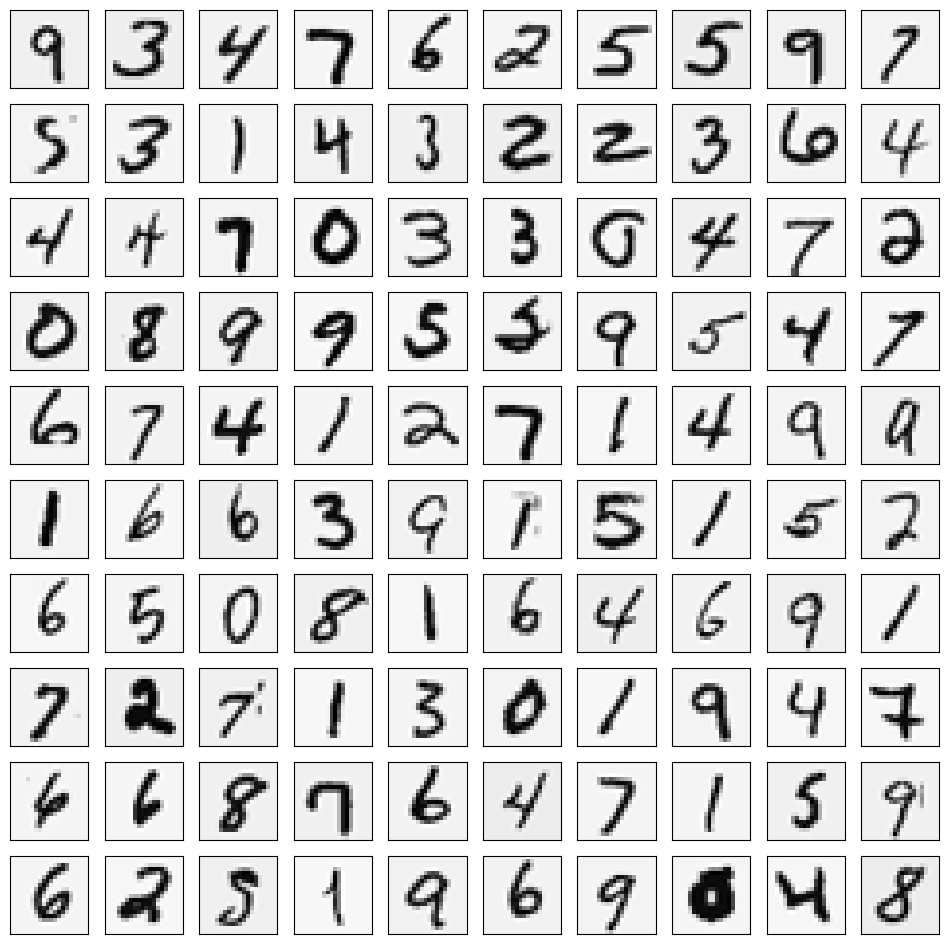

In [7]:
fig,ax_array = plt.subplots(nrows=10,ncols=10,sharey=True,sharex=True,figsize=(12,12))
for r in range(10):
    for c in range(10):
        ax_array[r,c].matshow(np.array(sample_images[10*r+c].reshape((20,20))).T,cmap=matplotlib.cm.binary)
        plt.xticks(np.array([]))
        plt.yticks(np.array([]))

In [8]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [10]:
def cost(theta,X,y,learningRate):
    theta = np.matrix(theta)
    X = np.matrix(X)
    y = np.matrix(y)
    first = np.multiply(-y,np.log(sigmoid(X*theta.T)))
    second = np.multiply(1-y,np.log(1-sigmoid(X*theta.T)))
    reg = (learningRate / (2*len(X)))*np.sum(np.power(theta[:,1:theta.shape[1]],2))
    return np.sum(first-second) /len(X)+reg

In [11]:
def gradient(theta,X,y,learningRate):
    theta = np.matrix(theta)
    X = np.matrix(X)
    y = np.matrix(y)

    parameters = int(theta.ravel().shape[1])
    error = sigmoid(X*theta.T) -y

    grad = ((X.T*error)/len(X)).T+((learningRate /len(X))*theta)

    return np.array(grad).ravel()

In [17]:
from scipy.optimize import minimize

def one_vs_all(X,y,num_labels,learning_rate):
    rows = X.shape[0]
    params = X.shape[1]

    all_theta = np.zeros((num_labels,params+1))

    X = np.insert(X,0,values=np.ones(rows),axis=1)

    for i in range(1,num_labels+1):
        theta = np.zeros(params +1)
        y_i = np.array([1 if label == i else 0 for label in y])
        y_i = np.reshape(y_i,(rows,1))

        fmin = minimize(fun=cost,x0=theta,args=(X,y_i,learning_rate),method='TNC',jac=gradient)
        all_theta[i-1,:] = fmin.x

    return all_theta

In [18]:
rows = data['X'].shape[0]
params = data['X'].shape[1]

all_theta = np.zeros((10,params +1))

X = np.insert(data['X'],0,values=np.ones(rows),axis=1)

theta = np.zeros(params +1)

y_0  = np.array([1 if label == 0 else 0 for label in data['y']])
y_0 = np.reshape(y_0,(rows,1))

X.shape,y_0.shape,theta.shape,all_theta.shape

((5000, 401), (5000, 1), (401,), (10, 401))

In [19]:
np.unique(data['y'])

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=uint8)

In [20]:
all_theta = one_vs_all(data['X'],data['y'],10,1)
all_theta

array([[-1.52015513e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.30683774e-03, -7.68238363e-10,  0.00000000e+00],
       [-2.60506996e+00,  0.00000000e+00,  0.00000000e+00, ...,
         4.23697588e-03, -4.82932176e-04,  0.00000000e+00],
       [-3.93876993e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.60391986e-05, -2.85457068e-07,  0.00000000e+00],
       ...,
       [-6.63599141e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.54353524e-04,  1.46045666e-05,  0.00000000e+00],
       [-3.88150000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.57253644e-03,  1.18600844e-04,  0.00000000e+00],
       [-3.45670793e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.18943240e-04,  1.07445463e-05,  0.00000000e+00]],
      shape=(10, 401))

In [21]:
def predict_all(X,all_theta):
    rows = X.shape[0]
    params = X.shape[1]
    num_labels = all_theta.shape[0]

    X = np.insert(X,0,values=np.ones(rows),axis=1)
    
    X = np.matrix(X)
    all_theta = np.matrix(all_theta)

    h=sigmoid(X*all_theta.T)

    h_argmax = np.argmax(h,axis=1)
    h_argmax+=1

    return h_argmax

In [23]:
y_pred = predict_all(data['X'],all_theta)
y_pred = np.asarray(y_pred).ravel()
print(classification_report(data['y'],y_pred))

              precision    recall  f1-score   support

           1       0.96      0.98      0.97       500
           2       0.94      0.92      0.93       500
           3       0.94      0.91      0.92       500
           4       0.95      0.96      0.95       500
           5       0.92      0.91      0.92       500
           6       0.97      0.98      0.97       500
           7       0.95      0.95      0.95       500
           8       0.92      0.93      0.92       500
           9       0.92      0.92      0.92       500
          10       0.97      0.99      0.98       500

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



In [24]:
weight = loadmat(r"C:\Users\chenq\My Work\吴恩达机器学习作业\ex3weights.mat")
theta1,theta2 = weight['Theta1'],weight['Theta2']
theta1.shape,theta2.shape

((25, 401), (10, 26))

In [25]:
X2 = np.matrix(np.insert(data['X'],0,values=np.ones(X.shape[0]),axis=1))
y2 = np.matrix(data['y'])
X2.shape,y2.shape

((5000, 401), (5000, 1))

In [28]:
a1 = X2
z2 = a1*theta1.T
z2.shape

(5000, 25)

In [29]:
a2 = sigmoid(z2)
a2.shape

(5000, 25)

In [31]:
a2 = np.insert(a2,0,values=np.ones(a2.shape[0]),axis=1)
z3 = a2*theta2.T
z3.shape

(5000, 10)

In [32]:
a3 = sigmoid(z3)
a3

matrix([[1.12661530e-04, 1.74127856e-03, 2.52696959e-03, ...,
         4.01468105e-04, 6.48072305e-03, 9.95734012e-01],
        [4.79026796e-04, 2.41495958e-03, 3.44755685e-03, ...,
         2.39107046e-03, 1.97025086e-03, 9.95696931e-01],
        [8.85702310e-05, 3.24266731e-03, 2.55419797e-02, ...,
         6.22892325e-02, 5.49803551e-03, 9.28008397e-01],
        ...,
        [5.17641791e-02, 3.81715020e-03, 2.96297510e-02, ...,
         2.15667361e-03, 6.49826950e-01, 2.42384687e-05],
        [8.30631310e-04, 6.22003774e-04, 3.14518512e-04, ...,
         1.19366192e-02, 9.71410499e-01, 2.06173648e-04],
        [4.81465717e-05, 4.58821829e-04, 2.15146201e-05, ...,
         5.73434571e-03, 6.96288990e-01, 8.18576980e-02]],
       shape=(5000, 10))

In [33]:
y_pred2 = np.argmax(a3,axis=1)+1
y_pred2.shape

(5000, 1)

In [35]:
y2 = np.asarray(y2).ravel()
print(classification_report(y2,y_pred))

              precision    recall  f1-score   support

           1       0.96      0.98      0.97       500
           2       0.94      0.92      0.93       500
           3       0.94      0.91      0.92       500
           4       0.95      0.96      0.95       500
           5       0.92      0.91      0.92       500
           6       0.97      0.98      0.97       500
           7       0.95      0.95      0.95       500
           8       0.92      0.93      0.92       500
           9       0.92      0.92      0.92       500
          10       0.97      0.99      0.98       500

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000

